# ADALL Week 6 Session 2 Practical:
## Reasoning and Justification
## SHAP Explanation Lab

**Target duration:** 130 minutes

This session continues the Week 6 explainability theme. The dataset remains unchanged.

Main flow:

```text
load same classification dataset → train XGBoost → calculate SHAP → explain global and local predictions → write recommendation
```

### Timing overview

| Chapter | Suggested time |
|---|---:|
| Setup and same dataset | 15 min |
| Train model | 20 min |
| SHAP idea and values | 20 min |
| Global SHAP plots | 30 min |
| Local SHAP explanation | 25 min |
| Recommendation writing | 20 min |
| **Total** | **130 min** |

## Chapter 1. Setup

**Suggested time:** 10 minutes

Run this first. SHAP may take a little time to install in Colab.

In [ ]:
!pip -q install shap xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report

from xgboost import XGBClassifier
import shap
import xgboost

RANDOM_STATE = 42

print('Setup complete')
print('shap:', shap.__version__)
print('xgboost:', xgboost.__version__)

Setup complete
shap: 0.52.0
xgboost: 3.2.0


## Chapter 2. Load the same Week 6 dataset

**Suggested time:** 5 minutes

Do not change the dataset. This keeps Session 1 and Session 2 connected.

In [ ]:
data = load_breast_cancer(as_frame=True)

df = data.frame.copy()
TARGET_COL = 'target'
target_names = dict(enumerate(data.target_names))

print('Target names:', target_names)
print('Shape:', df.shape)
df.head()

Target names: {0: np.str_('malignant'), 1: np.str_('benign')}
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Chapter 3. Split the data

**Suggested time:** 10 minutes

Use the same train-test split idea as Session 1.

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (455, 30)
X_test : (114, 30)


## Chapter 4. Train a simple XGBoost classifier

**Suggested time:** 15 minutes

SHAP is commonly used with tree-based models. Here, we train one XGBoost model so that the explanation section is focused.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=1
)

xgb_model.fit(X_train, y_train)

pred = xgb_model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, pred), 3))
print('F1      :', round(f1_score(y_test, pred), 3))
print('MCC     :', round(matthews_corrcoef(y_test, pred), 3))
print('\nConfusion matrix:')
print(confusion_matrix(y_test, pred))

Accuracy: 0.956
F1      : 0.966
MCC     : 0.906

Confusion matrix:
[[38  4]
 [ 1 71]]


## Chapter 5. What SHAP is

**Suggested time:** 10 minutes

SHAP explains how features push a model prediction.

Simple meaning:

```text
For this prediction, which features pushed the prediction higher or lower?
```

Two views are useful:

| View | Question answered |
|---|---|
| Global SHAP | Which features matter overall? |
| Local SHAP | Why did the model predict this one row this way? |

Important warning:

```text
SHAP explains the model. It does not prove real-world cause.
```

## Chapter 6. Calculate SHAP values

**Suggested time:** 10 minutes

Use a sample of the training data as background. This keeps the lab fast enough for class.

In [ ]:
# Explain a small test sample so the lab runs quickly in class.
X_explain = X_test.iloc[:60].copy()
y_explain = y_test.iloc[:60].copy()
pred_explain = xgb_model.predict(X_explain)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_explain)

print('Rows explained:', X_explain.shape[0])
print('SHAP values shape:', shap_values.values.shape)

Rows explained: 60
SHAP values shape: (60, 30)


## Chapter 7. Global SHAP bar plot

**Suggested time:** 10 minutes

The bar plot ranks features by average SHAP impact.

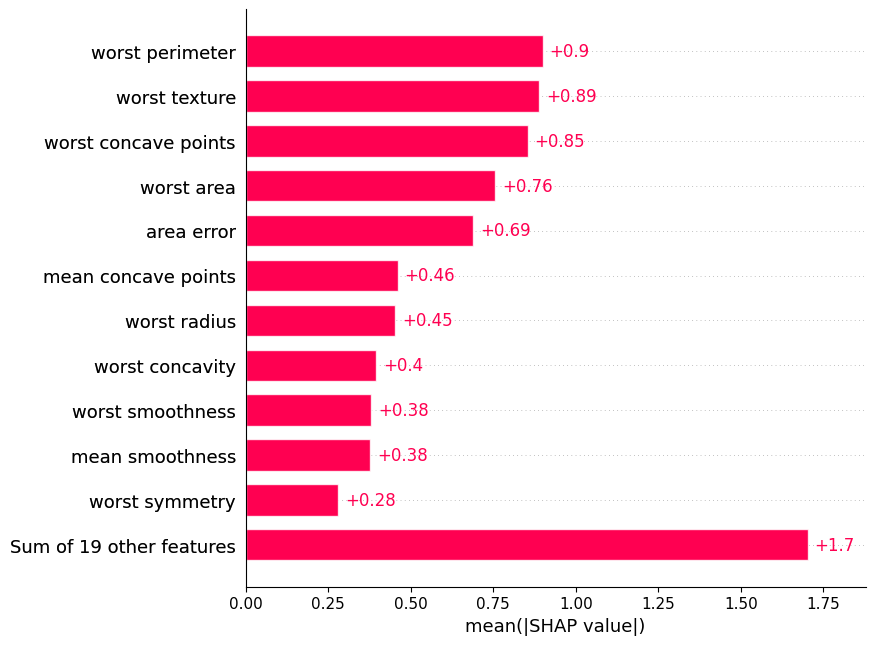

In [ ]:
shap.plots.bar(shap_values, max_display=12)

### What to check

The top features are the ones with the largest average impact on model output.

Write:

```text
The top global SHAP features are ______, ______, and ______.
```

## Chapter 8. Global SHAP beeswarm plot

**Suggested time:** 10 minutes

The beeswarm plot shows both importance and direction.

| Colour / position idea | Meaning |
|---|---|
| High feature value on one side | High values push prediction in that direction |
| Low feature value on the other side | Low values push prediction in the opposite direction |
| Wide spread | Feature has strong or varied impact |

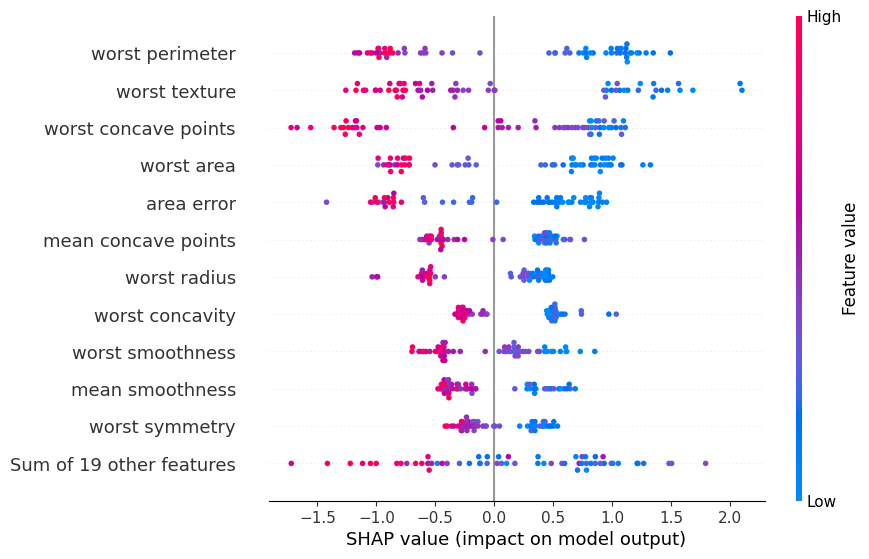

In [ ]:
shap.plots.beeswarm(shap_values, max_display=12)

## Chapter 9. Dependence plot for one feature

**Suggested time:** 10 minutes

A dependence plot focuses on one feature and shows how its value relates to SHAP impact.

Top SHAP feature: worst perimeter


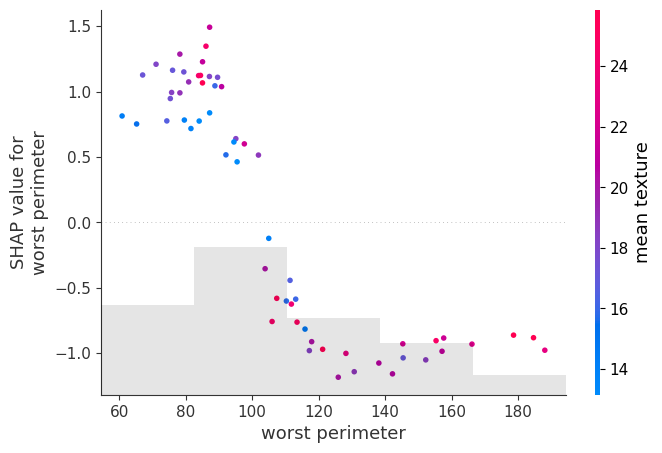

In [ ]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_feature_index = mean_abs_shap.argmax()
top_feature = X_explain.columns[top_feature_index]

print('Top SHAP feature:', top_feature)

shap.plots.scatter(shap_values[:, top_feature], color=shap_values)

### What to check

Describe the pattern carefully:

```text
As ______ increases, the SHAP value generally ______.
This means the model prediction is pushed ______.
```

## Chapter 10. Explain one prediction using a waterfall plot

**Suggested time:** 15 minutes

A local explanation looks at one row only.

In [ ]:
row_id = 0

print('Actual class:', y_explain.iloc[row_id])
print('Predicted class:', pred_explain[row_id])
print('Target names:', target_names)

X_explain.iloc[[row_id]]

Actual class: 0
Predicted class: 0
Target names: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
256,19.55,28.77,133.6,1207.0,0.0926,0.2063,0.1784,0.1144,0.1893,0.06232,...,25.05,36.27,178.6,1926.0,0.1281,0.5329,0.4251,0.1941,0.2818,0.1005


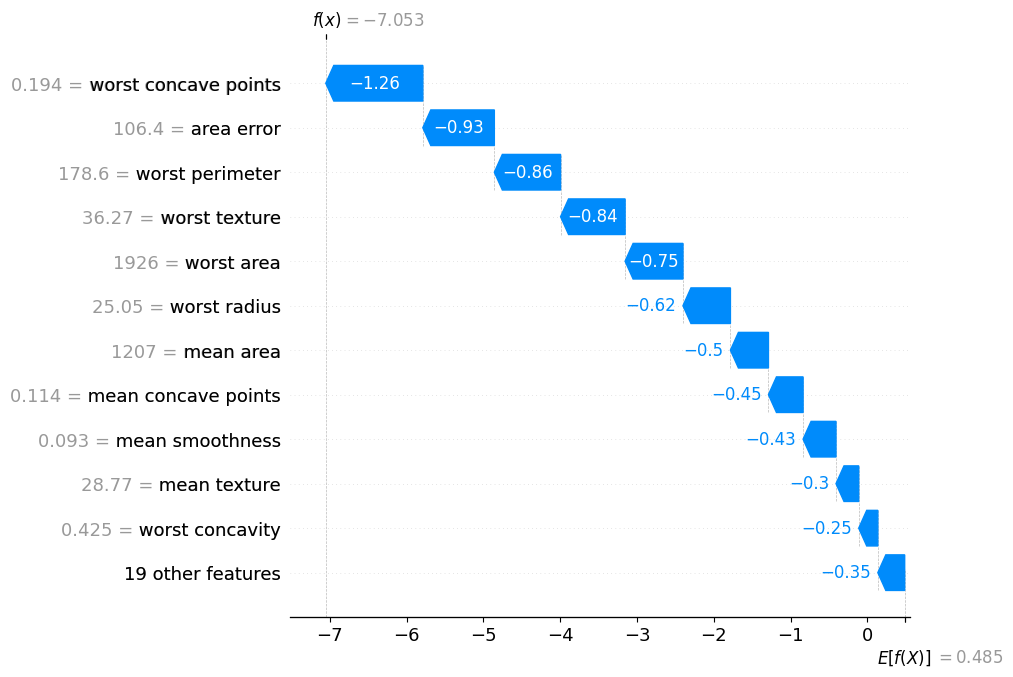

In [ ]:
shap.plots.waterfall(shap_values[row_id], max_display=12)

### What to check

Write a local explanation:

```text
For this row, the model predicted ______.
The features that pushed the prediction most were ______.
The features that pushed against the prediction were ______.
```

## Chapter 11. Build a SHAP evidence table

**Suggested time:** 10 minutes

This table helps you write a clear explanation without relying only on the plot.

In [ ]:
local_shap_df = pd.DataFrame({
    'feature': X_explain.columns,
    'value': X_explain.iloc[row_id].values,
    'shap_value': shap_values[row_id].values
})

local_shap_df['absolute_shap'] = local_shap_df['shap_value'].abs()
local_shap_df.sort_values('absolute_shap', ascending=False).head(10)

,feature,value,shap_value,absolute_shap
27,worst concave points,0.1941,-1.263268,1.263268
13,area error,106.4000,-0.931411,0.931411
22,worst perimeter,178.6000,-0.862179,0.862179
21,worst texture,36.2700,-0.840325,0.840325
23,worst area,1926.0000,-0.753423,0.753423
20,worst radius,25.0500,-0.617814,0.617814
3,mean area,1207.0000,-0.495159,0.495159
7,mean concave points,0.1144,-0.451011,0.451011
4,mean smoothness,0.0926,-0.428462,0.428462
1,mean texture,28.7700,-0.295707,0.295707


## Chapter 12. Link SHAP back to project recommendation

**Suggested time:** 15 minutes

A good explanation connects model evidence to a careful decision. It does not overclaim.

In [ ]:
global_top = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

evidence_summary = f'''
Model: XGBoost classifier
Accuracy: {accuracy_score(y_test, pred):.3f}
F1: {f1_score(y_test, pred):.3f}
MCC: {matthews_corrcoef(y_test, pred):.3f}

Top global SHAP features:
{global_top.head(5).to_string(index=False)}

Top local SHAP features for row {row_id}:
{local_shap_df.sort_values('absolute_shap', ascending=False).head(5).to_string(index=False)}
'''

print(evidence_summary)


Model: XGBoost classifier
Accuracy: 0.956
F1: 0.966
MCC: 0.906

Top global SHAP features:
             feature  mean_abs_shap
     worst perimeter       0.899096
       worst texture       0.889001
worst concave points       0.854345
          worst area       0.755718
          area error       0.689188

Top local SHAP features for row 0:
             feature     value  shap_value  absolute_shap
worst concave points    0.1941   -1.263268       1.263268
          area error  106.4000   -0.931411       0.931411
     worst perimeter  178.6000   -0.862179       0.862179
       worst texture   36.2700   -0.840325       0.840325
          worst area 1926.0000   -0.753423       0.753423



### Final written answer

Use this structure:

```text
The model performance is ______ based on ______.
The global SHAP plot suggests that ______, ______ and ______ are important to the model.
For one selected row, the model predicted ______.
The local SHAP explanation suggests that ______ pushed the prediction most.
This explanation is useful because ______.
However, I should not claim causation because SHAP explains the model, not the real-world medical cause.
```

### End checkpoint

You should now be able to explain:

1. the difference between global and local explanation,
2. how SHAP differs from normal feature importance,
3. why explanation is not the same as causation.

# Optional Reading: SHAP, FI, and pFI comparison

| Method | Main question | Caveat |
|---|---|---|
| Feature Importance | Which features did the tree model use strongly? | Internal to model training |
| Permutation Feature Importance | Which features hurt performance when shuffled? | Depends on test data and metric |
| SHAP | How do features push predictions higher or lower? | Explains the model, not causation |

# Additional Practice

Change `row_id` to another number and rerun the local explanation cells.

Then answer:

```text
Did the top local features change?
Why might two rows have different explanations even though the same model was used?
```